(Ch. 9 applied exercise 4) Generate a simulated two-class data set with 100 observations and two
features in which there is a visible but non-linear separation between the two classes. Show that in this
setting, a support vector machine with a polynomial kernel (with degree greater than 1) or a radial
kernel will outperform a support vector classifier on the training data. Which technique performs
best on the test data? Make plots and report training and test error rates in order to back up your
assertions.

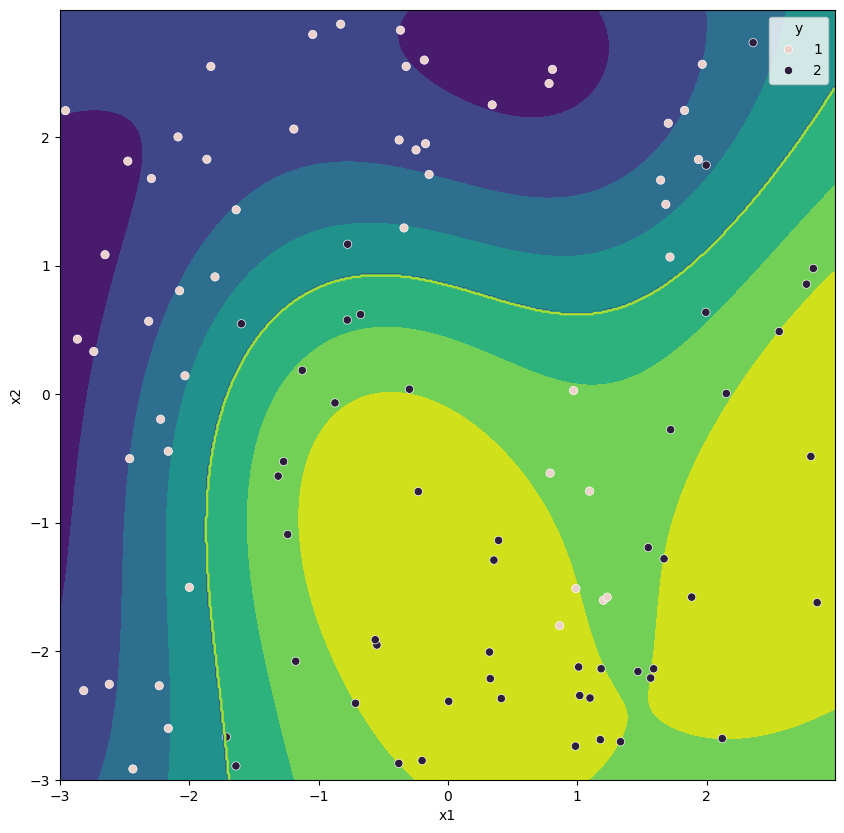

Training score: 0.89
Test score: 0.79


In [166]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn import svm
import seaborn as sns
import pandas as pd

def plot_clf(model, df, grid_range, show_contours=False, show_support_vectors=False):
    # Decision boundary plot
    
    # Get grid of values in given range
    x1 = grid_range
    x2 = grid_range
    xx1, xx2 = np.meshgrid(x1, x2, sparse=False)
    Xgrid = np.stack((xx1.flatten(), xx2.flatten())).T
    
    # Get decision boundary values for plot grid
    decision_boundary      = model.predict(Xgrid)
    decision_boundary_grid = decision_boundary.reshape(len(x2), len(x1))
    
    # Get decision function values for plot grid
    decision_function      = model.decision_function(Xgrid)
    decision_function_grid = decision_function.reshape(len(x2), len(x1))
    
    fig = plt.figure(figsize=(10, 10))
    if show_contours:
        plt.contourf(x1, x2, decision_function_grid);
    plt.contour(x1, x2, decision_boundary_grid);
    
    sns.scatterplot(x='x1', y='x2', hue='y', data=df)
    if show_support_vectors:
        sns.scatterplot(x=model.support_vectors_[:,0], y=model.support_vectors_[:,1], color='red', marker='+', s=500)
    plt.show();

rng = np.random.default_rng(42)

X = rng.uniform(-3, 3, 200)
y = rng.uniform(-3, 3, 200) 

above_line = y >  X ** 3 - 3 * X

X_train = np.column_stack((X[0:100], y[0:100]))
y_train = np.where(above_line[0:100], 1, 2)

X_test = np.column_stack((X[100:200], y[100:200]))
y_test = np.where(above_line[100:200], 1, 2)

df = pd.concat([pd.DataFrame(data=X_train, columns=['x1', 'x2']), pd.Series(y_train, name='y')], axis=1)
model = svm.SVC(kernel='rbf', C=1).fit(X_train, y_train)
plot_clf(model, df, np.arange(-3, 3, .01), show_contours=True)

print("Training score:", model.score(X_train, y_train))
print("Test score:", model.score(X_test, y_test))

array([[-1.99941406,  1.99941406]])

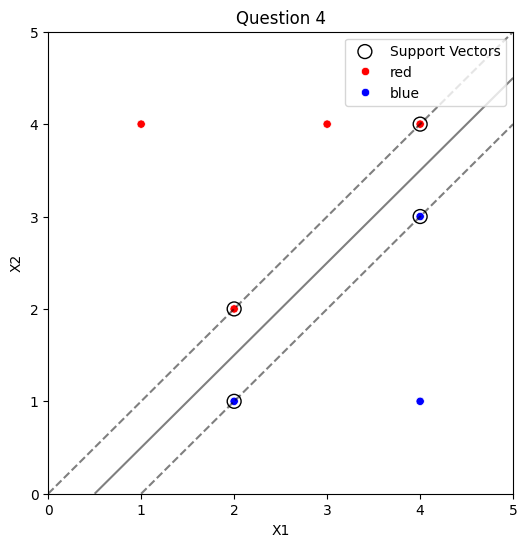

In [172]:
from sklearn.inspection import DecisionBoundaryDisplay

X1 = [3,2,4,1,2,4,4]
X2 = [4,2,4,4,1,3,1]
y = ['red','red','red','red','blue','blue','blue']

fig, ax = plt.subplots(figsize=(6, 6))
model = svm.SVC(kernel='linear', C=1000).fit(np.column_stack((X1, X2)), y)
DecisionBoundaryDisplay.from_estimator(
    model,
    np.column_stack((X1, X2)),
    plot_method="contour",
    colors="k",
    levels=[-1, 0, 1],
    alpha=0.5,
    linestyles=["--", "-", "--"],
    ax=ax,
)

#x_series = np.linspace(0.8, 5, 100)
#y_series = 0.8 * x_series 

#ax.plot(x_series, y_series, color='black', linestyle='-', label='X2 = 0.8X1')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title('Question 4')
ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100, facecolors='none', edgecolors='k', label='Support Vectors')
sns.scatterplot(x=X1, y=X2, hue=y, palette=['red', 'blue'], ax=ax)

model.coef_

[]

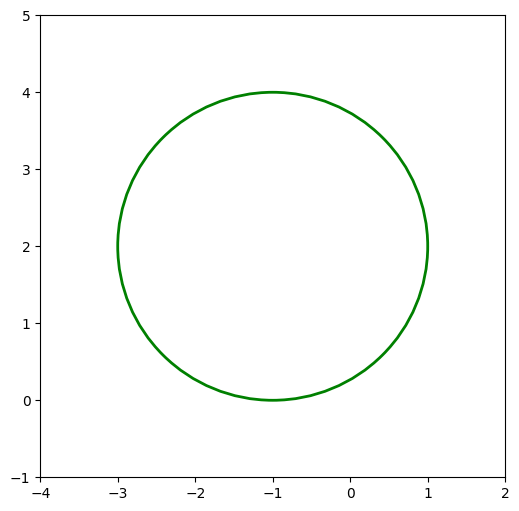

In [ ]:
import matplotlib.patches as patches 
fig, ax = plt.subplots(figsize=(6, 6))
circle = patches.Circle((-1, 2), 2, edgecolor='green', facecolor='none', linewidth=2)
ax.add_patch(circle)
ax.set_xlim(-4, 2)
ax.set_ylim(-1, 5)
ax.plot()